<a href="https://colab.research.google.com/github/Myllertg/customer-segmentation-kmeans/blob/main/Customer-Segmentation-Kmeans-EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Problem Understanding

## 1.1 Business Objective

The objective of this project is to **segment a financial institution's customers into groups with similar characteristics and behaviors**, using data related to their credit profile and banking relationship.

This segmentation will help identify distinct customer profiles and support the development of more targeted commercial and relationship strategies.

## 1.2 Problem Type

The project uses **Unsupervised Machine Learning**, framed as a **Clustering** problem.

The **K-Means** algorithm will be used to group customers with similar characteristics into distinct clusters, without the need for a predefined target variable.

## 1.3 Success Metrics

Cluster quality will be evaluated primarily using the **Silhouette Score** and **Inertia (WCSS)**. The **Elbow Method** will also be applied to help determine the optimal number of clusters.

In addition to statistical evaluation, the clusters must provide **interpretable profiles and clear business relevance**, enabling the identification of actionable differences across customer segments.

In [1]:
# DATA COLLECTION
# KAGGLE API INSTALLATION
!pip install -q kaggle

# SETUP & IMPORTS
from pathlib import Path
import os
import zipfile
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path("./data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATASET = "aryashah2k/credit-card-customer-data"

# DATASET DOWNLOAD
!kaggle datasets download -d {DATASET} -p {DATA_DIR}

# ZIP FILE IDENTIFICATION
zip_files = list(DATA_DIR.glob("*.zip"))

if not zip_files:
    raise FileNotFoundError(
        "No ZIP file was found after download."
    )

ZIP_PATH = zip_files[0]

print("=" * 70)
print("DOWNLOAD COMPLETED")
print("=" * 70)
print(f"Dataset: {DATASET}")
print(f"File: {ZIP_PATH.name}")

# FILE EXTRACTION
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DATA_DIR)

print("\nExtracted files:")

for file in DATA_DIR.iterdir():
    if file.is_file():
        print(f" - {file.name}")

# CSV IDENTIFICATION
csv_files = list(DATA_DIR.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "No CSV file was found after extraction."
    )

CSV_PATH = csv_files[0]

# DATA LOADING
df = pd.read_csv(CSV_PATH)

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/credit-card-customer-data
License(s): CC0-1.0
100% 6.28k/6.28k [00:00<00:00, 21.5MB/s]

DOWNLOAD COMPLETED
Dataset: aryashah2k/credit-card-customer-data
File: credit-card-customer-data.zip

Extracted files:
 - Credit Card Customer Data.csv
 - credit-card-customer-data.zip


1. DATASET OVERVIEW
Records................: 660
Columns................: 7
Memory usage...........: 0.04 MB
Missing values.........: 0
Duplicate records......: 0

2. DATA STRUCTURE


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4


,Type,Nulls,% Nulls,Unique Values
Sl_No,int64,0,0.00,660
Customer Key,int64,0,0.00,655
Avg_Credit_Limit,int64,0,0.00,110
Total_Credit_Cards,int64,0,0.00,10
Total_visits_bank,int64,0,0.00,6
Total_visits_online,int64,0,0.00,16
Total_calls_made,int64,0,0.00,11



3. DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Sl_No,660.00,330.50,190.67,1.00,165.75,330.50,495.25,660.00
Customer Key,660.00,"55,141.44","25,627.77","11,265.00","33,825.25","53,874.50","77,202.50","99,843.00"
Avg_Credit_Limit,660.00,"34,574.24","37,625.49","3,000.00","10,000.00","18,000.00","48,000.00","200,000.00"
Total_Credit_Cards,660.00,4.71,2.17,1.00,3.00,5.00,6.00,10.00
Total_visits_bank,660.00,2.40,1.63,0.00,1.00,2.00,4.00,5.00
Total_visits_online,660.00,2.61,2.94,0.00,1.00,2.00,4.00,15.00
Total_calls_made,660.00,3.58,2.87,0.00,1.00,3.00,5.00,10.00



4. CLUSTERING VARIABLES
Candidate variables: 5
- Avg_Credit_Limit
- Total_Credit_Cards
- Total_visits_bank
- Total_visits_online
- Total_calls_made

5. OUTLIER ANALYSIS


,Variable,Q1,Q3,Lower Limit,Upper Limit,Outliers,% Outliers
0,Avg_Credit_Limit,"10,000.00","48,000.00","-47,000.00","105,000.00",39,5.91%
1,Total_Credit_Cards,3.00,6.00,-1.50,10.50,0,0.00%
2,Total_visits_bank,1.00,4.00,-3.50,8.50,0,0.00%
3,Total_visits_online,1.00,4.00,-3.50,8.50,37,5.61%
4,Total_calls_made,1.00,5.00,-5.00,11.00,0,0.00%



6. CORRELATION MATRIX


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Avg_Credit_Limit,1.00,0.61,-0.10,0.55,-0.41
Total_Credit_Cards,0.61,1.00,0.32,0.17,-0.65
Total_visits_bank,-0.10,0.32,1.00,-0.55,-0.51
Total_visits_online,0.55,0.17,-0.55,1.00,0.13
Total_calls_made,-0.41,-0.65,-0.51,0.13,1.00


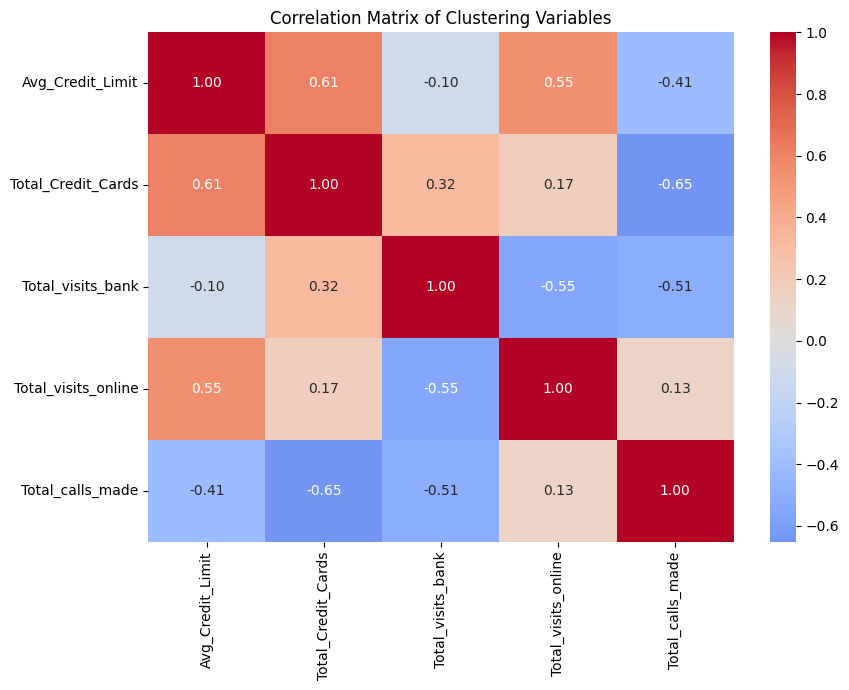


7. VARIABLE DISTRIBUTIONS


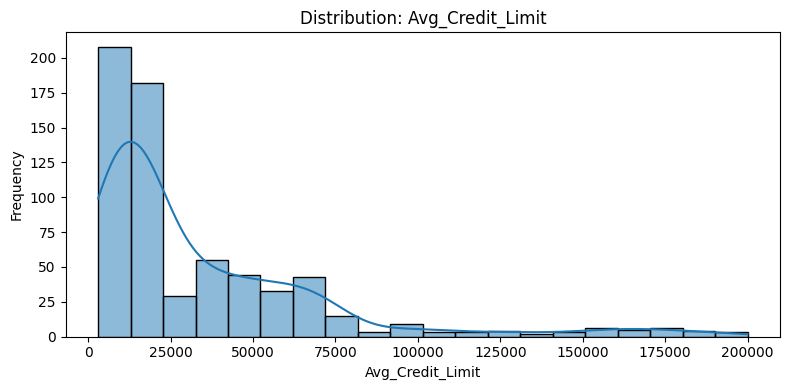

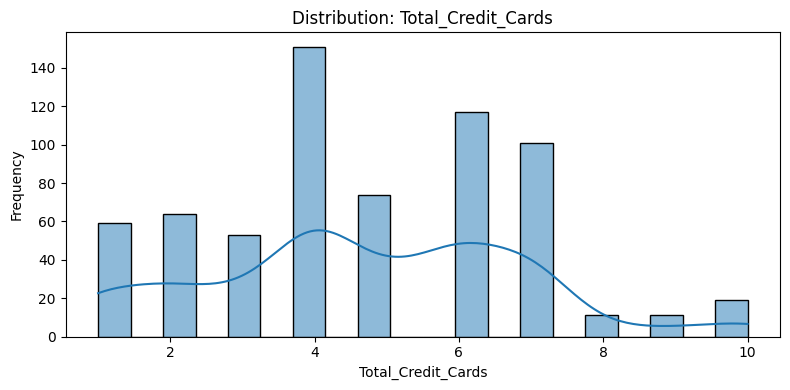

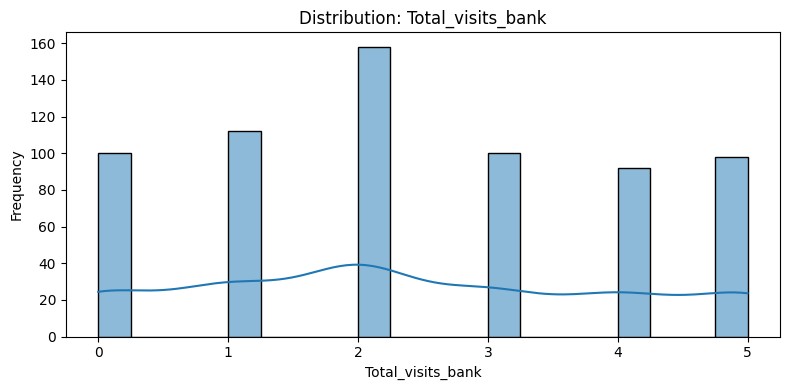

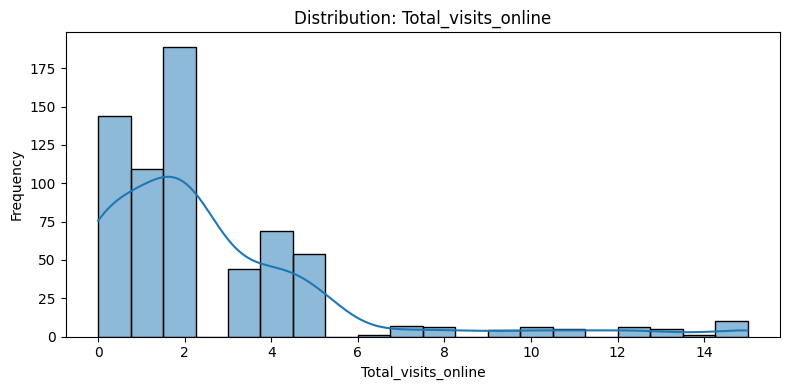

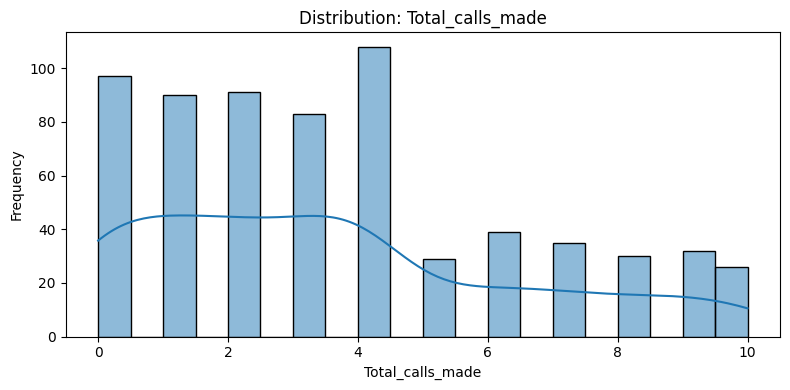


8. RELATIONSHIPS BETWEEN VARIABLES


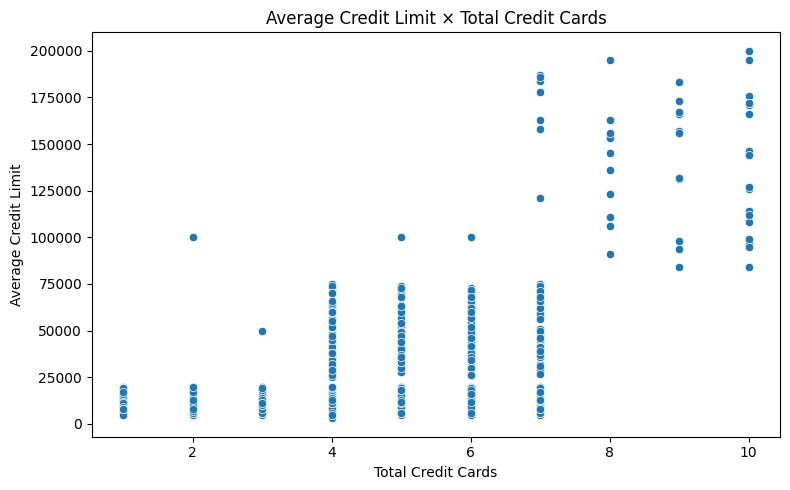

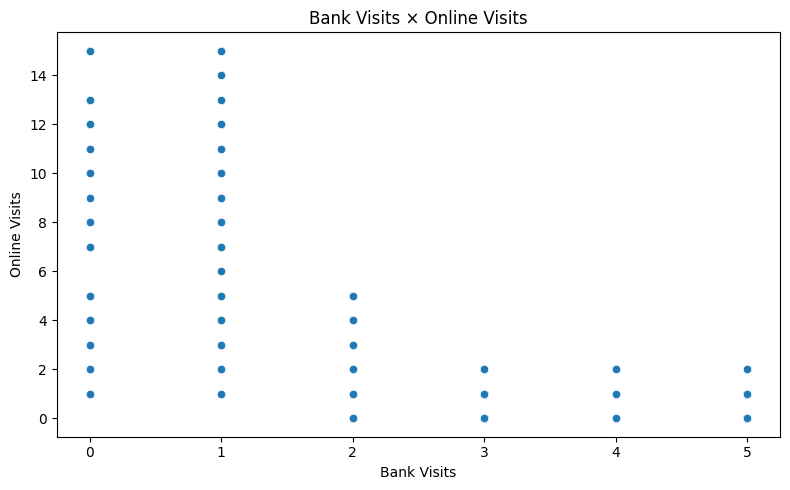

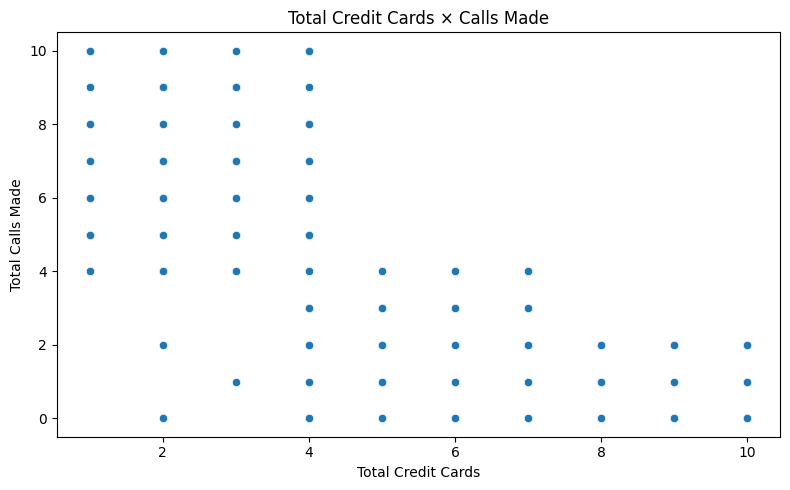


9. CUSTOMERS WITH HIGHEST CREDIT LIMIT


,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
630,33837,200000,10,0,13,0
631,14916,195000,8,0,15,0
650,78996,195000,10,1,12,2
632,97935,187000,7,1,7,0
646,58392,186000,7,0,8,1
639,90839,184000,7,1,15,2
647,79953,183000,9,0,9,2
624,97285,178000,7,0,11,0
622,53916,176000,10,1,15,2
637,88442,173000,9,1,11,0



10. CUSTOMERS WITH HIGHEST ONLINE USAGE


,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
640,99843,123000,8,1,15,2
658,80655,172000,10,1,15,0
653,51826,95000,10,0,15,1
620,32107,108000,10,0,15,1
622,53916,176000,10,1,15,2
628,75009,84000,9,1,15,0
639,90839,184000,7,1,15,2
644,18519,127000,10,1,15,1
645,48762,171000,10,0,15,0
631,14916,195000,8,0,15,0



11. DUPLICATE CUSTOMER KEYS
Duplicate Customer Keys: 5


,Count
Customer Key,
96929,2
47437,2
50706,2
37252,2
97935,2



Corresponding records:


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
48,49,37252,6000,4,0,2,8
432,433,37252,59000,6,2,1,2
332,333,47437,17000,7,3,1,0
4,5,47437,100000,6,0,12,3
411,412,50706,44000,4,5,0,2
541,542,50706,60000,7,5,2,2
391,392,96929,13000,4,5,0,0
398,399,96929,67000,6,2,2,2
104,105,97935,17000,2,1,2,10
632,633,97935,187000,7,1,7,0


In [2]:
# EXPLORATORY DATA ANALYSIS (EDA)

# SETTINGS
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# OVERVIEW
print("=" * 80)
print("1. DATASET OVERVIEW")
print("=" * 80)

duplicates = df.duplicated().sum()

print(f"Records................: {df.shape[0]:,}")
print(f"Columns................: {df.shape[1]}")
print(f"Memory usage...........: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Missing values.........: {df.isna().sum().sum():,}")
print(f"Duplicate records......: {duplicates:,}")


# DATA STRUCTURE
print("\n" + "=" * 80)
print("2. DATA STRUCTURE")
print("=" * 80)

display(df.head(3))

info_df = pd.DataFrame({
    "Type": df.dtypes,
    "Nulls": df.isna().sum(),
    "% Nulls": (df.isna().mean() * 100).round(2),
    "Unique Values": df.nunique()
})

display(info_df)


# DESCRIPTIVE STATISTICS
print("\n" + "=" * 80)
print("3. DESCRIPTIVE STATISTICS")
print("=" * 80)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

display(
    df[numeric_cols]
    .describe()
    .T
)


# DEFINING VARIABLES FOR CLUSTERING
print("\n" + "=" * 80)
print("4. CLUSTERING VARIABLES")
print("=" * 80)

# Identifiers that do not represent customer characteristics
identifiers = [
    "Sl_No",
    "Customer Key"
]

# Candidate features
candidate_cols = [
    col for col in numeric_cols
    if col not in identifiers
]

print(f"Candidate variables: {len(candidate_cols)}")

for col in candidate_cols:
    print(f"- {col}")


# OUTLIER ANALYSIS
print("\n" + "=" * 80)
print("5. OUTLIER ANALYSIS")
print("=" * 80)

outliers = []

for col in candidate_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    n_outliers = (
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ).sum()

    outliers.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Outliers": n_outliers,
        "% Outliers": round(
            n_outliers / len(df) * 100,
            2
        )
    })

outliers_df = pd.DataFrame(outliers)

display(
    outliers_df.style.format({
        "Q1": "{:,.2f}",
        "Q3": "{:,.2f}",
        "Lower Limit": "{:,.2f}",
        "Upper Limit": "{:,.2f}",
        "% Outliers": "{:.2f}%"
    })
)


# CORRELATION MATRIX
print("\n" + "=" * 80)
print("6. CORRELATION MATRIX")
print("=" * 80)

correlation = df[candidate_cols].corr()

display(
    correlation.round(2)
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Clustering Variables")
plt.tight_layout()
plt.show()


# VARIABLE DISTRIBUTIONS
print("\n" + "=" * 80)
print("7. VARIABLE DISTRIBUTIONS")
print("=" * 80)

for col in candidate_cols:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True
    )

    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# RELATIONSHIPS BETWEEN KEY VARIABLES
print("\n" + "=" * 80)
print("8. RELATIONSHIPS BETWEEN VARIABLES")
print("=" * 80)

# Credit Limit vs. Number of Credit Cards
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Total_Credit_Cards",
    y="Avg_Credit_Limit"
)

plt.title("Average Credit Limit × Total Credit Cards")
plt.xlabel("Total Credit Cards")
plt.ylabel("Average Credit Limit")

plt.tight_layout()
plt.show()

# Bank Visits vs. Online Visits
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Total_visits_bank",
    y="Total_visits_online"
)

plt.title("Bank Visits × Online Visits")
plt.xlabel("Bank Visits")
plt.ylabel("Online Visits")

plt.tight_layout()
plt.show()

# Credit Cards vs. Customer Service Calls
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Total_Credit_Cards",
    y="Total_calls_made"
)

plt.title("Total Credit Cards × Calls Made")
plt.xlabel("Total Credit Cards")
plt.ylabel("Total Calls Made")

plt.tight_layout()
plt.show()


# HIGH CREDIT LIMIT CUSTOMERS
print("\n" + "=" * 80)
print("9. CUSTOMERS WITH HIGHEST CREDIT LIMIT")
print("=" * 80)

display(
    df[
        [
            "Customer Key",
            "Avg_Credit_Limit",
            "Total_Credit_Cards",
            "Total_visits_bank",
            "Total_visits_online",
            "Total_calls_made"
        ]
    ]
    .sort_values(
        "Avg_Credit_Limit",
        ascending=False
    )
    .head(15)
)


# HIGH ONLINE USAGE CUSTOMERS
print("\n" + "=" * 80)
print("10. CUSTOMERS WITH HIGHEST ONLINE USAGE")
print("=" * 80)

display(
    df[
        [
            "Customer Key",
            "Avg_Credit_Limit",
            "Total_Credit_Cards",
            "Total_visits_bank",
            "Total_visits_online",
            "Total_calls_made"
        ]
    ]
    .sort_values(
        "Total_visits_online",
        ascending=False
    )
    .head(15)
)


# REPEATED CUSTOMER KEYS
print("\n" + "=" * 80)
print("11. DUPLICATE CUSTOMER KEYS")
print("=" * 80)

customer_key_counts = df["Customer Key"].value_counts()

repeated_keys = customer_key_counts[
    customer_key_counts > 1
]

print(
    f"Duplicate Customer Keys: {len(repeated_keys)}"
)

if len(repeated_keys) > 0:

    display(
        repeated_keys
        .rename("Count")
        .to_frame()
    )

    print("\nCorresponding records:")

    display(
        df[
            df["Customer Key"].isin(
                repeated_keys.index
            )
        ]
        .sort_values("Customer Key")
    )

else:

    print("No duplicate Customer Keys found.")

# Data Understanding and Exploratory Data Analysis (EDA)

In this step, an exploratory analysis of the dataset containing **660 records and 7 variables** was performed to understand the data structure, identify quality issues, and evaluate which variables best represent customer behavior for K-Means.

The dataset showed **no missing values and no duplicated records**, indicating good structural quality.

The variables `Sl_No` and `Customer Key` were identified as **identifiers** and, therefore, will not be used as features in the clustering process.

The five selected behavioral variables were:

- `Avg_Credit_Limit`
- `Total_Credit_Cards`
- `Total_visits_bank`
- `Total_visits_online`
- `Total_calls_made`

## Scale and Outliers

Statistical analysis revealed significant scale differences across variables. The main example is `Avg_Credit_Limit`, which ranges from **3,000 to 200,000**, while the other variables operate within much narrower intervals.

Potential outliers were also identified in:

- `Avg_Credit_Limit`: **39 records (5.91%)**
- `Total_visits_online`: **37 records (5.61%)**

These values were retained because they likely represent real customer behaviors that are relevant for identifying specific market segments.

This scale disparity must be addressed later through **feature scaling (standardization)** to prevent variables with larger numerical magnitudes from disproportionately influencing the K-Means distance calculations.

## Feature Correlation

Correlation analysis revealed several relevant relationships:

- `Avg_Credit_Limit` × `Total_Credit_Cards`: **0.61**
- `Avg_Credit_Limit` × `Total_visits_online`: **0.55**
- `Total_Credit_Cards` × `Total_calls_made`: **-0.65**
- `Total_visits_bank` × `Total_calls_made`: **-0.51**

These relationships indicate distinct usage patterns across products and service channels.

For instance, customers with higher credit limits tend to hold more credit cards and interact more through online channels. Conversely, the negative correlation between the number of credit cards and customer service calls may point to customer profiles with different relationship models with the institution.

## Initial Analysis of Customer Behavior

Customers with the highest credit limits and highest online channel usage were also analyzed.

This preliminary inspection indicated that customers with higher limits frequently have a greater number of credit cards and higher digital channel engagement.

At the same time, there are customers with lower limits who rely more heavily on phone customer service.

These behavioral patterns reinforce the likely existence of **distinct customer profiles** that can be identified through clustering.

## Duplicate Customer Keys

The analysis identified **5 duplicate Customer Keys**, accounting for **10 total records**.

Since the objective of this project is customer segmentation, where each record must represent a unique unit of analysis, these duplicates were investigated.

The decision was made to address these occurrences during the data preparation phase, ensuring each customer is uniquely represented prior to running K-Means.

## Primary Insight

The exploratory analysis demonstrated that the dataset has sufficient quality for K-Means and exhibits **clear behavioral heterogeneity among customers**, primarily regarding:

- Credit limit
- Number of credit cards
- Branch visits
- Online channel usage
- Phone support interactions

This heterogeneity is essential because the primary objective of K-Means is to identify distinct groups that are internally homogeneous and mutually differentiated.

## Conclusion

The EDA provided a solid understanding of the dataset's core characteristics and defined the features to be used in modeling.

The key decisions were:

- `Sl_No` and `Customer Key` will be excluded from the model;
- The five behavioral variables will be used for clustering;
- Outliers will be retained;
- Duplicate Customer Keys will be handled;
- Variables will be standardized prior to applying K-Means.

In [3]:
# DATA CLEANING AND PREPARATION
# COPY OF ORIGINAL DATASET
df_clean = df.copy()



# INVESTIGATION OF DUPLICATE CUSTOMER KEYS
print("\n" + "=" * 80)
print("1. DUPLICATE CUSTOMER KEYS")
print("=" * 80)

customer_key_counts = df_clean["Customer Key"].value_counts()

repeated_keys = customer_key_counts[
    customer_key_counts > 1
]

print(
    f"Duplicate Customer Keys: {len(repeated_keys)}"
)

if len(repeated_keys) > 0:

    print("\nDuplicate keys:")

    display(
        repeated_keys
        .rename("Record Count")
        .to_frame()
    )

    print("\nRecords associated with duplicate keys:")

    conflicting_records = (
        df_clean[
            df_clean["Customer Key"].isin(
                repeated_keys.index
            )
        ]
        .sort_values("Customer Key")
    )

    display(conflicting_records)



else:

    print(
        "\nNo duplicate Customer Keys found."
    )



# MODELING DATASET
df_model = df_clean.copy()

print("\n" + "=" * 80)
print("2. MODELING DATASET")
print("=" * 80)

print(f"Records in original dataset: {len(df_clean):,}")
print(f"Records removed: {len(df_clean) - len(df_model):,}")
print(f"Records for modeling: {len(df_model):,}")

print(
    f"Unique Customer Keys: "
    f"{df_model['Customer Key'].nunique():,}"
)

print(
    f"Duplicate Customer Keys retained: "
    f"{len(repeated_keys):,}"
)


# FEATURE DEFINITION
print("\n" + "=" * 80)
print("3. K-MEANS FEATURES")
print("=" * 80)

features = [
    "Avg_Credit_Limit",
    "Total_Credit_Cards",
    "Total_visits_bank",
    "Total_visits_online",
    "Total_calls_made"
]

for feature in features:
    print(f"- {feature}")


# CREATING THE FEATURE MATRIX
X = df_model[features].copy()

print("\n" + "=" * 80)
print("4. FEATURE MATRIX")
print("=" * 80)

print(f"Dimensions of X: {X.shape}")

display(X.head())


# DATA TYPE VERIFICATION
print("\n" + "=" * 80)
print("5. FEATURE DATA TYPES")
print("=" * 80)

display(
    X.dtypes.to_frame("Type")
)



# INVALID VALUE VERIFICATION
print("\n" + "=" * 80)
print("6. INVALID VALUES")
print("=" * 80)

invalid_values = {}

for col in features:

    invalid_values[col] = {
        "Negative values": (X[col] < 0).sum(),
        "Zeros": (X[col] == 0).sum(),
        "Infinite values": np.isinf(X[col]).sum()
    }

invalid_df = pd.DataFrame(invalid_values).T

display(invalid_df)


# BOUNDARY AND METRIC VALIDATION
print("\n" + "=" * 80)
print("7. VALUE VALIDATION")
print("=" * 80)

validation = pd.DataFrame({
    "Minimum": X.min(),
    "Maximum": X.max(),
    "Mean": X.mean(),
    "Median": X.median(),
    "Standard Deviation": X.std()
})

display(
    validation.style.format("{:,.2f}")
)


# FINAL OUTLIER VERIFICATION
print("\n" + "=" * 80)
print("8. OUTLIERS")
print("=" * 80)

outlier_summary = []

for col in features:

    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = (
        (X[col] < lower) |
        (X[col] > upper)
    ).sum()

    outlier_summary.append({
        "Variable": col,
        "Outliers": n_outliers,
        "%": n_outliers / len(X) * 100
    })

outlier_summary = pd.DataFrame(
    outlier_summary
)

display(
    outlier_summary.style.format({
        "%": "{:.2f}%"
    })
)

# SCALE COMPARISON
print("\n" + "=" * 80)
print("9. FEATURE SCALES")
print("=" * 80)

scale_comparison = pd.DataFrame({
    "Minimum": X.min(),
    "Maximum": X.max(),
    "Range": X.max() - X.min()
})

display(
    scale_comparison.style.format("{:,.2f}")
)


1. DUPLICATE CUSTOMER KEYS
Duplicate Customer Keys: 5

Duplicate keys:


,Record Count
Customer Key,
96929,2
47437,2
50706,2
37252,2
97935,2



Records associated with duplicate keys:


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
48,49,37252,6000,4,0,2,8
432,433,37252,59000,6,2,1,2
332,333,47437,17000,7,3,1,0
4,5,47437,100000,6,0,12,3
411,412,50706,44000,4,5,0,2
541,542,50706,60000,7,5,2,2
391,392,96929,13000,4,5,0,0
398,399,96929,67000,6,2,2,2
104,105,97935,17000,2,1,2,10
632,633,97935,187000,7,1,7,0



2. MODELING DATASET
Records in original dataset: 660
Records removed: 0
Records for modeling: 660
Unique Customer Keys: 655
Duplicate Customer Keys retained: 5

3. K-MEANS FEATURES
- Avg_Credit_Limit
- Total_Credit_Cards
- Total_visits_bank
- Total_visits_online
- Total_calls_made

4. FEATURE MATRIX
Dimensions of X: (660, 5)


...

,Minimum,Maximum,Mean,Median,Standard Deviation
Avg_Credit_Limit,"3,000.00","200,000.00","34,574.24","18,000.00","37,625.49"
Total_Credit_Cards,1.00,10.00,4.71,5.00,2.17
Total_visits_bank,0.00,5.00,2.40,2.00,1.63
Total_visits_online,0.00,15.00,2.61,2.00,2.94
Total_calls_made,0.00,10.00,3.58,3.00,2.87



8. OUTLIERS


,Variable,Outliers,%
0,Avg_Credit_Limit,39,5.91%
1,Total_Credit_Cards,0,0.00%
2,Total_visits_bank,0,0.00%
3,Total_visits_online,37,5.61%
4,Total_calls_made,0,0.00%



9. FEATURE SCALES


,Minimum,Maximum,Range
Avg_Credit_Limit,"3,000.00","200,000.00","197,000.00"
Total_Credit_Cards,1.00,10.00,9.00
Total_visits_bank,0.00,5.00,5.00
Total_visits_online,0.00,15.00,15.00
Total_calls_made,0.00,10.00,10.00


# Data Processing and Preparation

In this step, the dataset was prepared for the application of **K-Means**, taking into account the findings from the previous exploratory analysis and focusing on the necessary decisions to transform the data into a matrix suitable for the model.

## Duplicate Customer Keys

In the previous step, **5 duplicate Customer Keys** were identified, totaling **10 records**.

An individual analysis of these occurrences showed that the records associated with the same keys have different values across the behavioral variables. Therefore, these were not exact duplicates.

For example, the same `Customer Key` may appear associated with different credit limits, number of credit cards, and service channel usage.

Thus, there was insufficient evidence to determine that one of the records was incorrect. Excluding them could remove potentially valid information and artificially alter the composition of the segments.

**Decision:** all 10 records were retained in the dataset.

The `Customer Key` will continue to be used solely as an identifier for interpreting the results and will not be part of the variables used by K-Means.

## Building the Modeling Matrix

After defining the variables, the model's input matrix was constructed, containing exclusively the behavioral characteristics of the customers.

The features used were:

- `Avg_Credit_Limit`
- `Total_Credit_Cards`
- `Total_visits_bank`
- `Total_visits_online`
- `Total_calls_made`

The final matrix contains:

- **660 records**
- **5 features**

Dimensions of `X`:

**(660, 5)**

Identifiers were kept out of the modeling matrix, preventing information without behavioral significance from influencing cluster formation.

## Dataset Validation for Modeling

Prior to variable transformation, additional checks were performed to ensure that the matrix was suitable for the algorithm.

None of the following were found:

- Negative values
- Infinite values
- Data type issues

Values equal to zero were preserved, as they represent valid behaviors. For example, a customer may not visit the bank or may not use a specific service channel.

## Feature Standardization

The main transformation performed in this step was **feature standardization using `StandardScaler`**.

This transformation was necessary because the variables have different units and ranges. While `Avg_Credit_Limit` represents monetary values, the other features represent counts of cards, visits, and phone calls.

Since K-Means uses **Euclidean distance** to measure proximity between customers, working directly with raw variables could cause features with larger magnitudes to exert greater influence on the clustering.

`StandardScaler` transforms each variable to a comparable scale, with:

- Mean approximately equal to **0**
- Standard deviation approximately equal to **1**

This allows the model to jointly consider the different characteristics of the customers, without the unit of measurement of any single variable determining the clustering outcome.

## Preparation Summary

At the end of this step, a standardized matrix `X_scaled` was obtained with:

- **660 customers**
- **5 features**
- Numerical data suitable for the model
- Absence of infinite values
- Identifiers kept out of the modeling matrix
- Duplicate Customer Keys preserved
- Features standardized using `StandardScaler`

The dataset is therefore prepared for the application of the **K-Means** algorithm.

In [4]:
# FEATURE STANDARDIZATION
# ORIGINAL MATRIX VERIFICATION

print("=" * 80)
print("1. ORIGINAL MATRIX")
print("=" * 80)

print(f"Dimensions: {X.shape}")

display(X.head())

# INSTANTIATING STANDARD SCALER
scaler = StandardScaler()


# STANDARDIZATION
X_scaled_array = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=features,
    index=X.index
)


# STANDARDIZED MATRIX
print("\n" + "=" * 80)
print("2. STANDARDIZED MATRIX")
print("=" * 80)

display(
    X_scaled.head()
)

# MEAN VERIFICATION


print("\n" + "=" * 80)
print("3. MEANS AFTER STANDARDIZATION")
print("=" * 80)

display(
    X_scaled.mean()
    .to_frame("Mean")
)


# STANDARD DEVIATION VERIFICATION
print("\n" + "=" * 80)
print("4. STANDARD DEVIATIONS AFTER STANDARDIZATION")
print("=" * 80)

display(
    X_scaled.std()
    .to_frame("Standard Deviation")
)


# COMPARISON BEFORE VS. AFTER
print("\n" + "=" * 80)
print("5. SCALE COMPARISON")
print("=" * 80)

comparison = pd.DataFrame({
    "Mean Before": X.mean(),
    "Std Before": X.std(),
    "Mean After": X_scaled.mean(),
    "Std After": X_scaled.std()
})

display(
    comparison.style.format("{:.4f}")
)



# MISSING VALUE CHECK
print("\n" + "=" * 80)
print("6. STANDARDIZED MATRIX VALIDATION")
print("=" * 80)

print(f"Missing values: {X_scaled.isna().sum().sum()}")
print(f"Infinite values: {np.isinf(X_scaled).sum().sum()}")
print(f"Records: {X_scaled.shape[0]}")
print(f"Features: {X_scaled.shape[1]}")

1. ORIGINAL MATRIX
Dimensions: (660, 5)


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3



2. STANDARDIZED MATRIX


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.74,-1.25,-0.86,-0.55,-1.25
1,0.41,-0.79,-1.47,2.52,1.89
2,0.41,1.06,-0.86,0.13,0.15
3,-0.12,0.14,-0.86,-0.55,0.15
4,1.74,0.60,-1.47,3.20,-0.20



3. MEANS AFTER STANDARDIZATION


...


4. STANDARD DEVIATIONS AFTER STANDARDIZATION


,Standard Deviation
Avg_Credit_Limit,1.00
Total_Credit_Cards,1.00
Total_visits_bank,1.00
Total_visits_online,1.00
Total_calls_made,1.00



5. SCALE COMPARISON


,Mean Before,Std Before,Mean After,Std After
Avg_Credit_Limit,34574.2424,37625.4878,0.0000,1.0008
Total_Credit_Cards,4.7061,2.1678,0.0000,1.0008
Total_visits_bank,2.4030,1.6318,-0.0000,1.0008
Total_visits_online,2.6061,2.9357,0.0000,1.0008
Total_calls_made,3.5833,2.8653,-0.0000,1.0008



6. STANDARDIZED MATRIX VALIDATION
Missing values: 0
Infinite values: 0
Records: 660
Features: 5


# Feature Standardization

In this step, the **5 variables selected for K-Means** were standardized using the `StandardScaler` method.

Standardization was necessary because the variables exhibit **significantly different scales**, particularly `Avg_Credit_Limit`. Since K-Means relies on distance calculations to form clusters, the absence of standardization could allow variables with larger scales to exert a disproportionate influence on the grouping.

Following the transformation, the following results were obtained:

- **Records:** 660
- **Features:** 5
- **Variable means:** approximately 0
- **Standard deviations:** approximately 1
- **Missing values:** 0
- **Infinite values:** 0

Standardization does not alter the relative behavior of the customers. It merely places all variables on a **comparable scale**.

## Key Insight

With standardized variables, K-Means will be able to calculate distances between customers in a balanced manner, ensuring that **credit limit, total credit cards, and engagement across different channels** contribute equitably to cluster formation.

1. EVALUATION OF K VALUES
K =  2 | Inertia = 2,040.99 | Silhouette = 0.4184
K =  3 | Inertia = 933.04 | Silhouette = 0.5157
K =  4 | Inertia = 780.77 | Silhouette = 0.3557
K =  5 | Inertia = 704.48 | Silhouette = 0.2717
K =  6 | Inertia = 642.27 | Silhouette = 0.2560
K =  7 | Inertia = 599.93 | Silhouette = 0.2482
K =  8 | Inertia = 567.33 | Silhouette = 0.2271
K =  9 | Inertia = 542.25 | Silhouette = 0.2141
K = 10 | Inertia = 516.24 | Silhouette = 0.2137

2. COMPARATIVE RESULTS


,K,Inertia,Silhouette Score
0,2,"2,040.99",0.4184
1,3,933.04,0.5157
2,4,780.77,0.3557
3,5,704.48,0.2717
4,6,642.27,0.2560
5,7,599.93,0.2482
6,8,567.33,0.2271
7,9,542.25,0.2141
8,10,516.24,0.2137


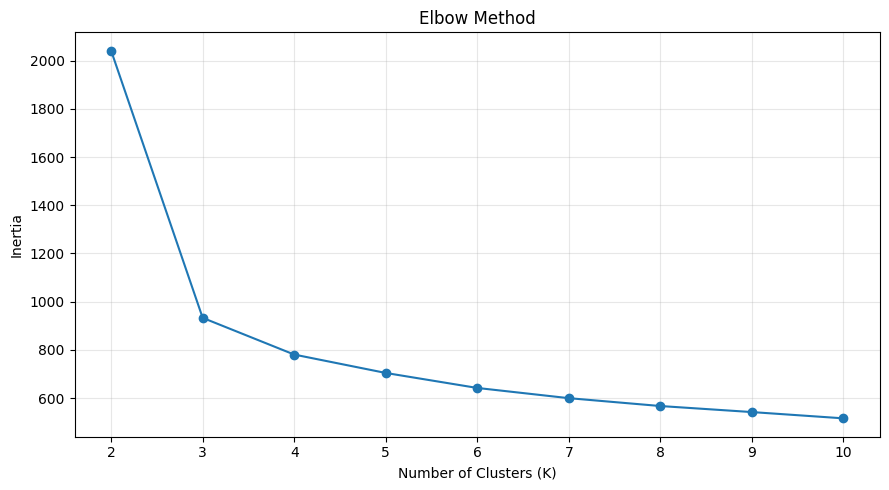

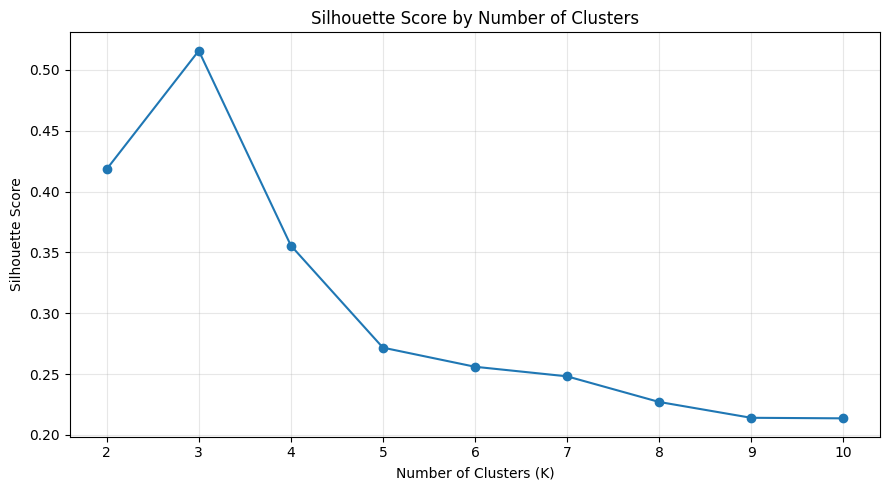


3. BEST RESULT ACCORDING TO SILHOUETTE
Best K: 3
Silhouette Score: 0.5157


In [5]:
# DETERMINING THE NUMBER OF CLUSTERS
# SETTING K VALUES

k_values = range(2, 11)

inertias = []
silhouette_scores = []

# MODEL TRAINING
print("=" * 80)
print("1. EVALUATION OF K VALUES")
print("=" * 80)

for k in k_values:

    # Create model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Train
    labels = kmeans.fit_predict(X_scaled)

    # Inertia
    inertias.append(kmeans.inertia_)

    # Silhouette Score
    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(silhouette)

    print(
        f"K = {k:2d} | "
        f"Inertia = {kmeans.inertia_:,.2f} | "
        f"Silhouette = {silhouette:.4f}"
    )


# COMPARATIVE TABLE
print("\n" + "=" * 80)
print("2. COMPARATIVE RESULTS")
print("=" * 80)

results_k = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

display(
    results_k.style.format({
        "Inertia": "{:,.2f}",
        "Silhouette Score": "{:.4f}"
    })
)


# ELBOW METHOD
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(list(k_values))

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


# SILHOUETTE SCORE
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(list(k_values))

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

# BEST K ACCORDING TO SILHOUETTE
best_k_silhouette = results_k.loc[
    results_k["Silhouette Score"].idxmax(),
    "K"
]

best_silhouette = results_k["Silhouette Score"].max()

print("\n" + "=" * 80)
print("3. BEST RESULT ACCORDING TO SILHOUETTE")
print("=" * 80)

print(f"Best K: {int(best_k_silhouette)}")
print(f"Silhouette Score: {best_silhouette:.4f}")

# Evaluation of the Number of Clusters

In this step, values of **K ranging from 2 to 10** were evaluated to determine the most suitable number of clusters for K-Means.

Two main criteria were used:

- **Inertia:** measures the distance of data points from the center of their respective clusters. Lower values indicate better compactness.
- **Silhouette Score:** simultaneously evaluates cluster cohesion and separation. Higher values indicate better-defined clusters.

## Results

The best result according to the **Silhouette Score** was achieved with:

- **K = 3**
- **Silhouette Score = 0.5157**
- **Inertia = 933.04**

K = 3 yielded the highest Silhouette Score among all evaluated configurations.

## Decision

**K = 3** was selected because it provided the optimal combination of cluster cohesion and separation, as indicated by the Silhouette Score.

Choosing K = 3 suggests that the data naturally organizes into **three customer segments with distinct behavioral characteristics**.

While inertia continues to decrease as the number of clusters increases (which is expected in K-Means), it should not be considered in isolation. The Silhouette Score was used as the primary decision metric, complemented by the elbow method analysis.

In [6]:
# DEFINING K
K = 3

# MODEL INSTANTIATION
kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

# TRAINING & PREDICTION
cluster_labels = kmeans.fit_predict(X_scaled)

# CREATING THE CLUSTERED DATASET
df_clustered = df_model.copy()

df_clustered["Cluster"] = cluster_labels

# RESULTS VERIFICATION
print("\n" + "=" * 80)
print("1. CLUSTERING RESULTS")
print("=" * 80)

print(f"Records analyzed: {len(df_clustered):,}")
print(f"Number of clusters: {df_clustered['Cluster'].nunique()}")

# CUSTOMER DISTRIBUTION PER CLUSTER
print("\n" + "=" * 80)
print("2. CLUSTER SIZES")
print("=" * 80)

cluster_counts = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_summary = pd.DataFrame({
    "Customer Count": cluster_counts,
    "Percentage of Total (%)":
        cluster_counts / len(df_clustered) * 100
})

display(
    cluster_summary.style.format({
        "Percentage of Total (%)": "{:.2f}%"
    })
)

# SAMPLE OF CLASSIFIED CUSTOMERS
print("\n" + "=" * 80)
print("3. SAMPLE OF CLASSIFIED CUSTOMERS")
print("=" * 80)

display(
    df_clustered[
        [
            "Customer Key",
            "Avg_Credit_Limit",
            "Total_Credit_Cards",
            "Total_visits_bank",
            "Total_visits_online",
            "Total_calls_made",
            "Cluster"
        ]
    ].head(20)
)


# CLUSTER CENTROIDS
centroids_scaled = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features
)

centroids_scaled.index.name = "Cluster"

print("\n" + "=" * 80)
print("4. STANDARDIZED CENTROIDS")
print("=" * 80)

display(
    centroids_scaled.style.format("{:.3f}")
)


# MODEL EVALUATION
from sklearn.metrics import silhouette_score

silhouette_final = silhouette_score(
    X_scaled,
    cluster_labels
)

print("\n" + "=" * 80)
print("5. MODEL EVALUATION")
print("=" * 80)

print(f"Final Silhouette Score: {silhouette_final:.4f}")
print(f"Final Inertia: {kmeans.inertia_:,.2f}")


1. CLUSTERING RESULTS
Records analyzed: 660
Number of clusters: 3

2. CLUSTER SIZES


,Customer Count,Percentage of Total (%)
Cluster,,
0,386,58.48%
1,50,7.58%
2,224,33.94%



3. SAMPLE OF CLASSIFIED CUSTOMERS


,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Cluster
0,87073,100000,2,1,1,0,0
1,38414,50000,3,0,10,9,2
2,17341,50000,7,1,3,4,0
3,40496,30000,5,1,1,4,0
4,47437,100000,6,0,12,3,1
5,58634,20000,3,0,1,8,2
6,48370,100000,5,0,11,2,1
7,37376,15000,3,0,1,1,2
8,82490,5000,2,0,2,2,2
9,44770,3000,4,0,1,7,2



4. STANDARDIZED CENTROIDS


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,-0.021,0.374,0.666,-0.554,-0.553
1,2.832,1.862,-1.106,2.827,-0.874
2,-0.596,-1.060,-0.902,0.323,1.148



5. MODEL EVALUATION
Final Silhouette Score: 0.5157
Final Inertia: 933.04


# K-Means Execution
With the model executed, each customer was assigned to the cluster showing the highest similarity to their behavioral characteristics.

## Clustering Results

The customer distribution is structured as follows:

- **Cluster 0:** 386 customers (58.48%)
- **Cluster 1:** 50 customers (7.58%)
- **Cluster 2:** 224 customers (33.94%)

The standardized centroids show that the three groups display distinct behavioral patterns, primarily regarding **credit limit, number of cards, and service channel preference**.

## Model Evaluation

- **Silhouette Score:** 0.5157
- **Inertia:** 933.04
- **Number of clusters:** 3

The Silhouette Score of **0.5157** indicates reasonable separation between groups, suggesting that customers within each cluster share similar characteristics and that the clusters maintain relevant differences between one another.


1. VARIABLE MEANS BY CLUSTER


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,"33,782.38",5.52,3.49,0.98,2.00
1,"141,040.00",8.74,0.60,10.90,1.08
2,"12,174.11",2.41,0.93,3.55,6.87



2. VARIABLE MEDIANS BY CLUSTER


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,"31,000.00",6.00,3.00,1.00,2.00
1,"145,500.00",9.00,1.00,11.00,1.00
2,"12,000.00",2.00,1.00,4.00,7.00



3. VARIABLE BOUNDS BY CLUSTER
MINIMUMS


...


4. COMPARISON WITH OVERALL MEAN
Percentage difference relative to overall mean:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,-2.29%,+17.20%,+45.22%,-62.32%,-44.19%
1,+307.93%,+85.72%,-75.03%,+318.26%,-69.86%
2,-64.79%,-48.77%,-61.17%,+36.36%,+91.74%



5. STANDARDIZED CLUSTER PROFILE


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,-0.02,+0.37,+0.67,-0.55,-0.55
1,+2.83,+1.86,-1.11,+2.83,-0.87
2,-0.60,-1.06,-0.90,+0.32,+1.15



6. DOMINANT CHARACTERISTICS

Cluster 0

Highest characteristics:
  + Total_visits_bank: 0.67
  + Total_Credit_Cards: 0.37

Lowest characteristics:
  - Total_visits_online: -0.55
  - Total_calls_made: -0.55

Cluster 1

Highest characteristics:
  + Avg_Credit_Limit: 2.83
  + Total_visits_online: 2.83

Lowest characteristics:
  - Total_visits_bank: -1.11
  - Total_calls_made: -0.87

Cluster 2

Highest characteristics:
  + Total_calls_made: 1.15
  + Total_visits_online: 0.32

Lowest characteristics:
  - Total_Credit_Cards: -1.06
  - Total_visits_bank: -0.90

7. CLUSTERS PROFILE MAP


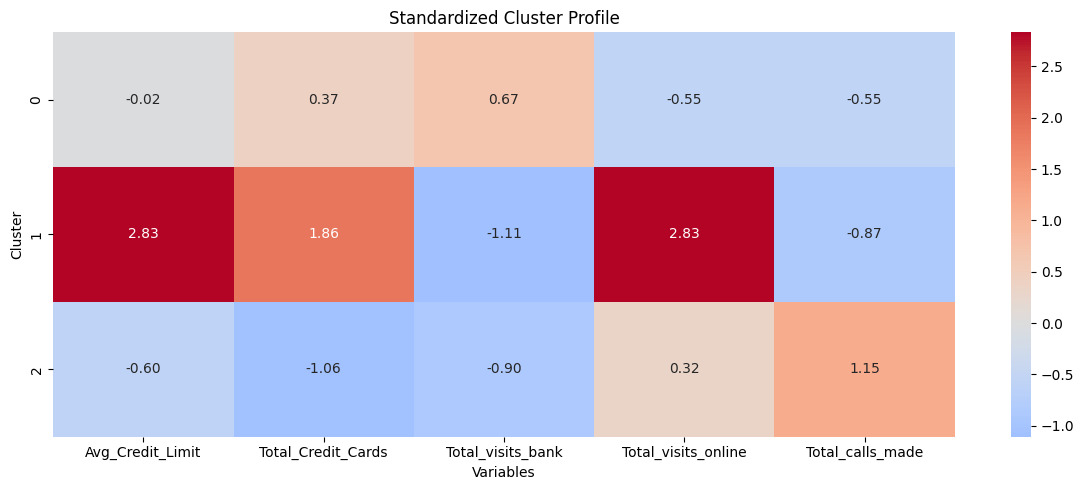

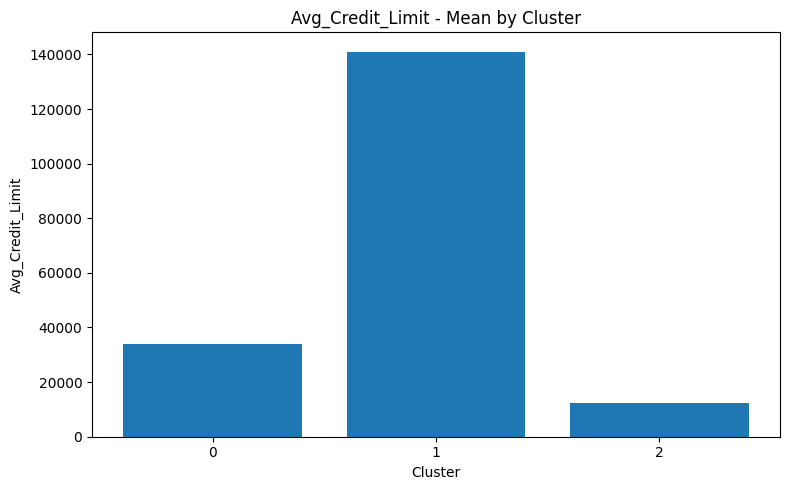

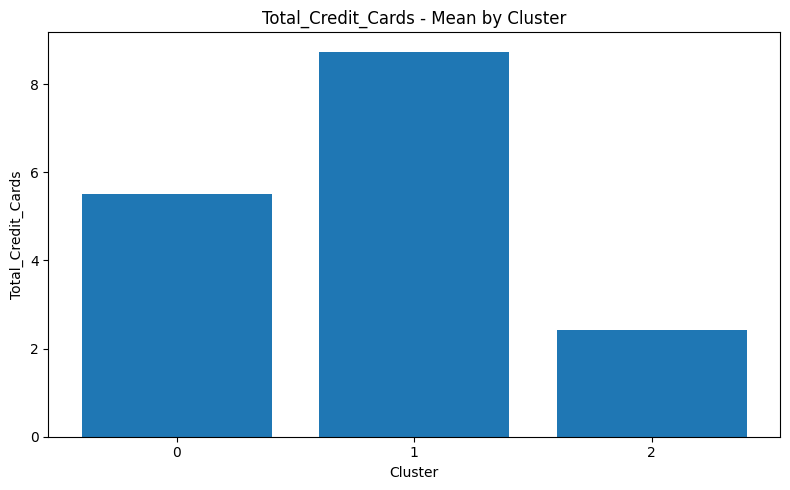

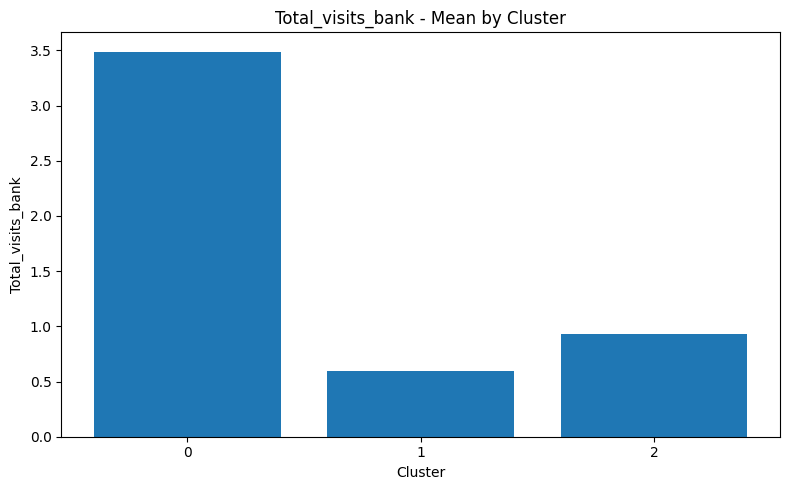

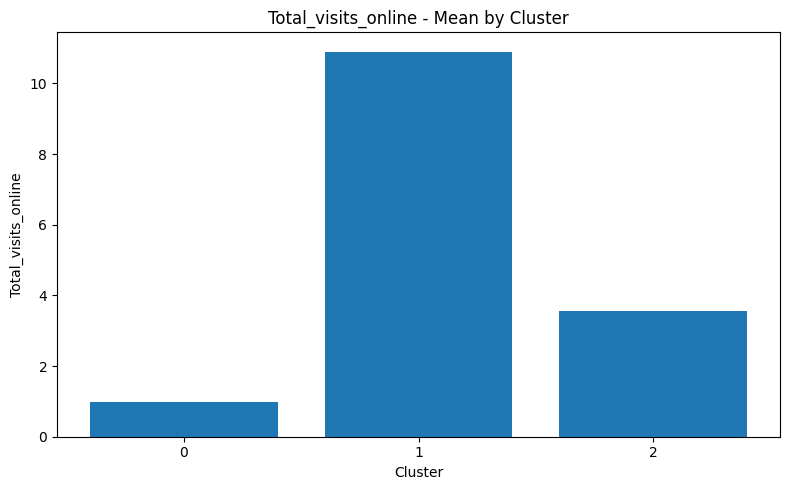

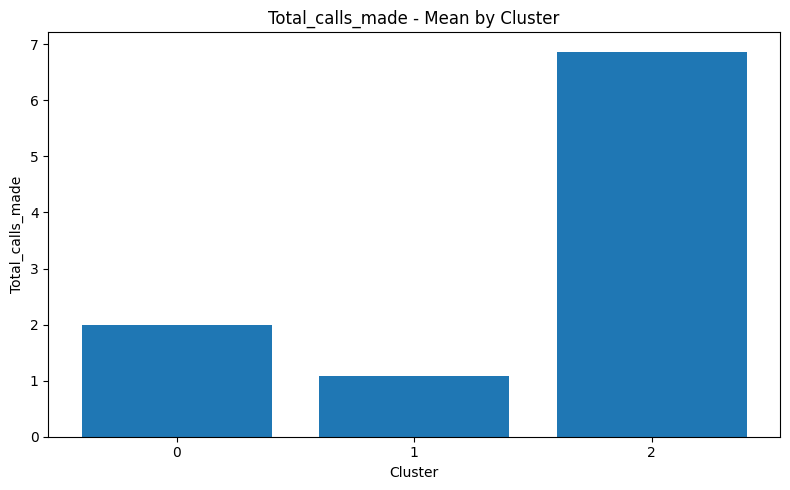


8. CUSTOMER DISTRIBUTION


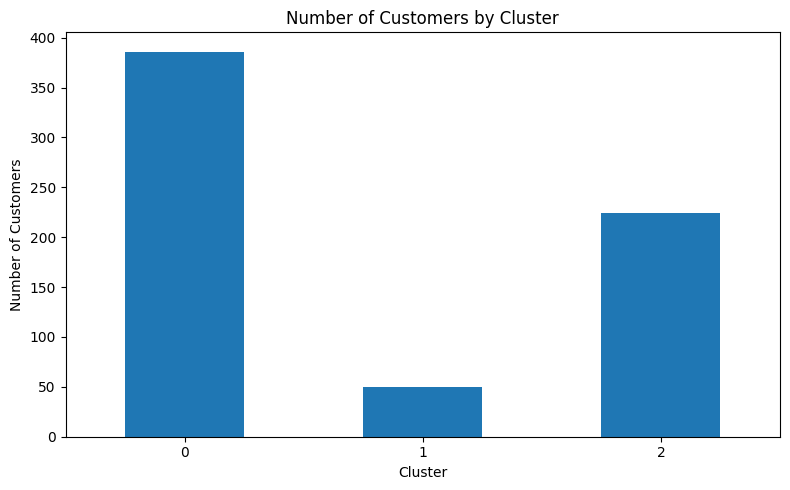


9. CLUSTERS EXECUTIVE SUMMARY


,Customers,% of Base,Avg Credit Limit,Median Credit Limit,Avg Credit Cards,Bank Visits,Online Visits,Calls Made
Cluster,,,,,,,,
0,386,58.48%,"33,782.38","31,000.00",5.52,3.49,0.98,2.00
1,50,7.58%,"141,040.00","145,500.00",8.74,0.60,10.90,1.08
2,224,33.94%,"12,174.11","12,000.00",2.41,0.93,3.55,6.87


In [7]:
# DATASET VERIFICATION
cluster_size = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

# VARIABLE MEANS BY CLUSTER
print("\n" + "=" * 80)
print("1. VARIABLE MEANS BY CLUSTER")
print("=" * 80)

cluster_mean = (
    df_clustered
    .groupby("Cluster")[features]
    .mean()
)

display(
    cluster_mean.style.format("{:,.2f}")
)


# VARIABLE MEDIANS BY CLUSTER
print("\n" + "=" * 80)
print("2. VARIABLE MEDIANS BY CLUSTER")
print("=" * 80)

cluster_median = (
    df_clustered
    .groupby("Cluster")[features]
    .median()
)

display(
    cluster_median.style.format("{:,.2f}")
)

# MINIMUM AND MAXIMUM BY CLUSTER
print("\n" + "=" * 80)
print("3. VARIABLE BOUNDS BY CLUSTER")
print("=" * 80)

cluster_min = (
    df_clustered
    .groupby("Cluster")[features]
    .min()
)

cluster_max = (
    df_clustered
    .groupby("Cluster")[features]
    .max()
)

print("MINIMUMS")
display(
    cluster_min.style.format("{:,.2f}")
)

print("\nMAXIMUMS")
display(
    cluster_max.style.format("{:,.2f}")
)


# COMPARISON WITH OVERALL MEAN
print("\n" + "=" * 80)
print("4. COMPARISON WITH OVERALL MEAN")
print("=" * 80)

overall_mean = df_clustered[features].mean()

cluster_vs_overall = (
    cluster_mean
    .subtract(overall_mean)
    .divide(overall_mean)
    * 100
)

print("Percentage difference relative to overall mean:")

display(
    cluster_vs_overall.style.format("{:+.2f}%")
)

# STANDARDIZED CLUSTER PROFILE
print("\n" + "=" * 80)
print("5. STANDARDIZED CLUSTER PROFILE")
print("=" * 80)

display(
    centroids_scaled.style.format("{:+.2f}")
)

# IDENTIFICATION OF HIGHEST AND LOWEST VALUES
print("\n" + "=" * 80)
print("6. DOMINANT CHARACTERISTICS")
print("=" * 80)

for cluster in centroids_scaled.index:

    print(f"\nCluster {cluster}")

    cluster_values = centroids_scaled.loc[cluster]

    top_features = cluster_values.sort_values(
        ascending=False
    ).head(2)

    bottom_features = cluster_values.sort_values(
        ascending=True
    ).head(2)

    print("\nHighest characteristics:")

    for feature, value in top_features.items():
        print(f"  + {feature}: {value:.2f}")

    print("\nLowest characteristics:")

    for feature, value in bottom_features.items():
        print(f"  - {feature}: {value:.2f}")


# CENTROIDS HEATMAP
print("\n" + "=" * 80)
print("7. CLUSTERS PROFILE MAP")
print("=" * 80)

plt.figure(figsize=(12, 5))

sns.heatmap(
    centroids_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Cluster Profile")
plt.xlabel("Variables")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

# MEAN COMPARISON
for feature in features:

    plt.figure(figsize=(8, 5))

    values = cluster_mean[feature]

    plt.bar(
        values.index.astype(str),
        values.values
    )

    plt.title(
        f"{feature} - Mean by Cluster"
    )

    plt.xlabel("Cluster")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()


# CUSTOMER DISTRIBUTION BY CLUSTER
print("\n" + "=" * 80)
print("8. CUSTOMER DISTRIBUTION")
print("=" * 80)

plt.figure(figsize=(8, 5))

cluster_size.plot(
    kind="bar"
)

plt.title("Number of Customers by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# EXECUTIVE SUMMARY TABLE
print("\n" + "=" * 80)
print("9. CLUSTERS EXECUTIVE SUMMARY")
print("=" * 80)

executive_profile = pd.DataFrame(index=cluster_mean.index)

executive_profile["Customers"] = cluster_size

executive_profile["% of Base"] = (
    cluster_size / len(df_clustered) * 100
)

executive_profile["Avg Credit Limit"] = (
    cluster_mean["Avg_Credit_Limit"]
)

executive_profile["Median Credit Limit"] = (
    cluster_median["Avg_Credit_Limit"]
)

executive_profile["Avg Credit Cards"] = (
    cluster_mean["Total_Credit_Cards"]
)

executive_profile["Bank Visits"] = (
    cluster_mean["Total_visits_bank"]
)

executive_profile["Online Visits"] = (
    cluster_mean["Total_visits_online"]
)

executive_profile["Calls Made"] = (
    cluster_mean["Total_calls_made"]
)

display(
    executive_profile.style.format({
        "% of Base": "{:.2f}%",
        "Avg Credit Limit": "{:,.2f}",
        "Median Credit Limit": "{:,.2f}",
        "Avg Credit Cards": "{:.2f}",
        "Bank Visits": "{:.2f}",
        "Online Visits": "{:.2f}",
        "Calls Made": "{:.2f}"
    })
)

# Cluster Analysis Conclusion

The cluster analysis made it possible to translate the groups generated by K-Means into **distinct behavioral profiles**.

## Cluster 0

Represents the largest group in the dataset, with **386 customers (58.48%)**.

It features an intermediate credit limit, a higher number of cards, and heavy reliance on physical branch visits. Online channel usage and call volumes are below the overall average.

**Profile:** Customers whose relationship is heavily concentrated on **in-person branch service**, holding a relatively high number of cards.

## Cluster 1

The smallest group, with **50 customers (7.58%)**, yet exhibiting highly specific characteristics.

It holds the highest average credit limit (**141,040**) and the highest average number of cards (**8.74**). It also shows strong online channel adoption (**10.90 visits**) alongside low usage of physical branches and phone support.

**Profile:** **High-value customers with a strong digital relationship**.

## Cluster 2

Accounts for **224 customers (33.94%)** and presents the lowest average credit limit (**12,174**) and the fewest cards (**2.41**).

At the same time, it concentrates the highest average number of calls (**6.87**), showing significantly higher telephone engagement than the other segments.

**Profile:** Customers with a **lower financial engagement level**, exhibiting higher dependence on phone support.

## Key Insight

The results demonstrate a clear segmentation structured primarily across three dimensions:

- **Financial value:** represented by credit limit and number of cards;
- **Channel preference:** physical branch, online, or telephone;
- **Relationship intensity:** volume of products held and total interactions with the institution.

This segmentation shifts the perspective from an individual analysis of 660 customer records to an actionable view of **three distinct behavioral segments**, streamlining the design of targeted strategies for each profile.

These clusters can serve as a foundation for **commercial campaigns, relationship management, customer care optimization, and personalized product offerings**, provided these hypotheses are subsequently validated against ongoing business metrics.


Explained variance by component:
PC1: 45.74%
PC2: 37.43%
Cumulative variance: 83.16%

Sample of data after PCA:


,PC1,PC2,Cluster
0,0.50,0.52,0
1,-1.46,3.11,2
2,0.53,0.82,0
3,-0.36,0.13,0
4,1.27,3.67,1


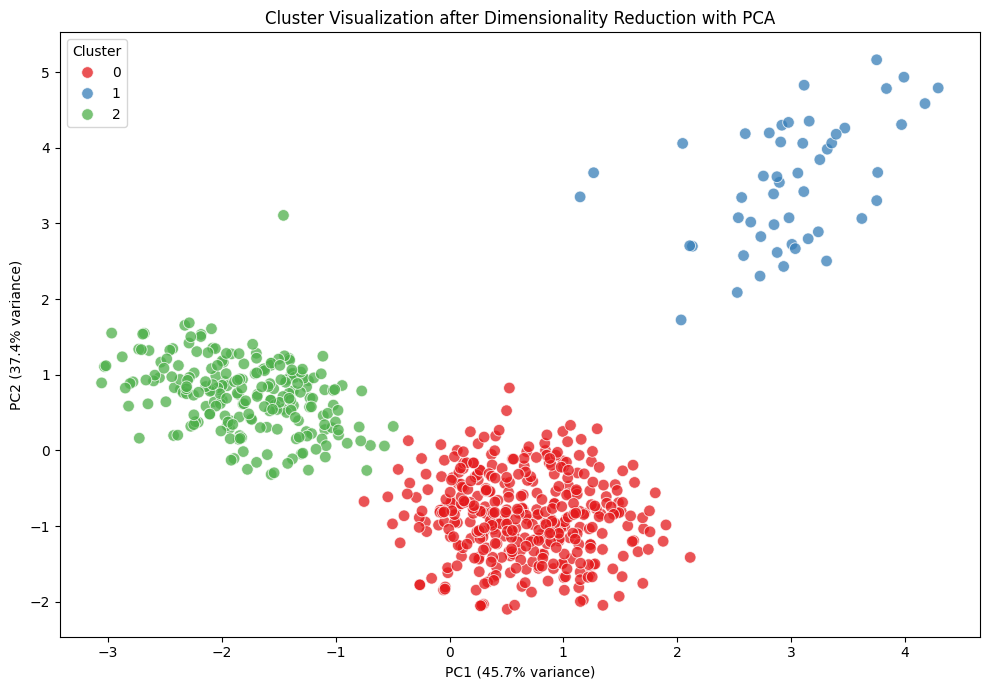

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


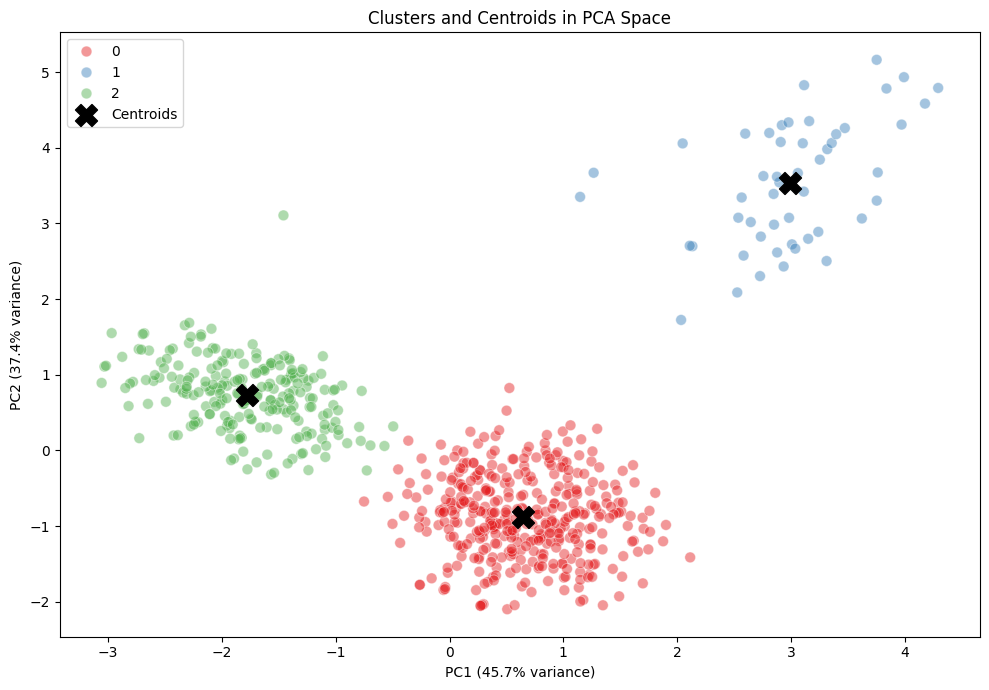

In [8]:
# VISUAL CLUSTER VALIDATION
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# EXPLAINED VARIANCE
explained_variance = pca.explained_variance_ratio_

print("\nExplained variance by component:")

print(
    f"PC1: {explained_variance[0] * 100:.2f}%"
)

print(
    f"PC2: {explained_variance[1] * 100:.2f}%"
)

print(
    f"Cumulative variance: "
    f"{explained_variance.sum() * 100:.2f}%"
)


# CREATE DATAFRAME FOR VISUALIZATION
df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Add clusters identified by K-Means
df_pca["Cluster"] = df_clustered["Cluster"].values

print("\nSample of data after PCA:")

display(df_pca.head())


# CLUSTER PLOT
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=70,
    alpha=0.75
)

plt.title(
    "Cluster Visualization after Dimensionality Reduction with PCA"
)

plt.xlabel(
    f"PC1 ({explained_variance[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1] * 100:.1f}% variance)"
)

plt.legend(
    title="Cluster"
)

plt.tight_layout()

plt.show()


# CLUSTER CENTROIDS IN PCA SPACE
centroids_pca = pca.transform(
    kmeans.cluster_centers_
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=60,
    alpha=0.45
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=250,
    c="black",
    label="Centroids"
)

plt.title(
    "Clusters and Centroids in PCA Space"
)

plt.xlabel(
    f"PC1 ({explained_variance[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1] * 100:.1f}% variance)"
)

plt.legend()

plt.tight_layout()

plt.show()

In [9]:
# FEATURE MATRIX FOR MODELING
X = df_model[features].copy()

# FINAL PIPELINE
RANDOM_STATE = 42
pipeline_kmeans = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "kmeans",
        KMeans(
            n_clusters=K,
            random_state=RANDOM_STATE,
            n_init=10
        )
    )
])


# FINAL MODEL TRAINING
pipeline_kmeans.fit(X)

# DATASET SEGMENTATION
clusters = pipeline_kmeans.predict(X)

df_model_output = df_model.copy()

df_model_output["Cluster"] = clusters

# PROFILE MAPPING
profiles = {
    0: "In-Person Relationship",
    1: "Digital Relationship",
    2: "Assisted Relationship"
}

df_model_output["Profile"] = (
    df_model_output["Cluster"]
    .map(profiles)
)

# FINAL SEGMENTATION DISTRIBUTION
distribution = (
    df_model_output["Cluster"]
    .value_counts()
    .sort_index()
)

distribution_df = pd.DataFrame({
    "Customers": distribution,
    "Percentage_of_Base": (
        distribution / len(df_model_output) * 100
    )
})


# SAMPLE OF SEGMENTED DATASET
print("\n" + "=" * 80)
print("SAMPLE OF SEGMENTED DATASET")
print("=" * 80)

display(
    df_model_output[
        [
            "Customer Key",
            "Cluster",
            "Profile"
        ]
    ].head(20)
)


# SAVING THE MODEL
model_file = "customer_segmentation_kmeans.pkl"

joblib.dump(
    pipeline_kmeans,
    model_file
)


# SAVING THE SEGMENTED DATASET
dataset_file = "segmented_customers.csv"

df_model_output.to_csv(
    dataset_file,
    index=False
)


# ARTIFACT VERIFICATION
print("\n" + "=" * 80)
print("GENERATED ARTIFACTS")
print("=" * 80)

print(f"Model: {model_file}")
print(f"Segmented dataset: {dataset_file}")

print("\nModel and segmented dataset successfully saved.")


SAMPLE OF SEGMENTED DATASET


,Customer Key,Cluster,Profile
0,87073,0,In-Person Relationship
1,38414,2,Assisted Relationship
2,17341,0,In-Person Relationship
3,40496,0,In-Person Relationship
4,47437,1,Digital Relationship
5,58634,2,Assisted Relationship
6,48370,1,Digital Relationship
7,37376,2,Assisted Relationship
8,82490,2,Assisted Relationship
9,44770,2,Assisted Relationship



GENERATED ARTIFACTS
Model: customer_segmentation_kmeans.pkl
Segmented dataset: segmented_customers.csv

Model and segmented dataset successfully saved.


# Operationalization and Customer Segmentation

In this step, the results obtained during model development were consolidated into a reusable segmentation pipeline.

A `Pipeline` combining `StandardScaler` and `KMeans` was created, ensuring that new customer data undergoes the exact same transformation workflow applied during training.

Following final training, each customer was assigned a **cluster** and a **behavioral profile**, translating the mathematical output of K-Means into an actionable business segmentation.

## Identified Profiles

- **In-Person Relationship:** Customers with higher physical branch usage and lower digital channel adoption.
- **Digital Relationship:** Customers with higher credit limits, a higher number of cards, and strong online channel engagement.
- **Assisted Relationship:** Customers with lower credit limits and fewer cards, but higher reliance on phone support.

These segment names reflect the **behavioral patterns observed in the data**, rather than a qualitative ranking of customer value.

## Deliverables

Two artifacts were generated for downstream use:

- `customer_segmentation_kmeans.pkl`: Trained pipeline containing both preprocessing and clustering steps, ready to score new customers.
- `segmented_customers.csv`: Dataset containing customer records mapped to their assigned clusters and behavioral profiles.

# Conclusion and Business Recommendations

The project applied the **K-Means** algorithm to identify customer behavior patterns based on five features related to their relationship with the financial institution:

- `Avg_Credit_Limit`
- `Total_Credit_Cards`
- `Total_visits_bank`
- `Total_visits_online`
- `Total_calls_made`

Following exploratory data analysis, data preparation, and feature standardization, multiple cluster configurations were evaluated. The configuration with **K = 3** produced the best result, achieving a **Silhouette Score of 0.5157**, indicating reasonable separation between the groups.

The final segmentation of the 660 customer records resulted in three distinct behavioral profiles:

| Segment | Customers | % of Base | Main Characteristic |
|---|---:|---:|---|
| **In-Person Relationship** | 386 | 58.48% | Highest physical branch usage |
| **Digital Relationship** | 50 | 7.58% | High credit limit, multiple cards, strong online usage |
| **Assisted Relationship** | 224 | 33.94% | Lower credit limit and highest phone call volume |

## 1. In-Person Relationship

This is the largest segment, representing **58.48% of the customer base**.

Average metrics:

- Credit limit: **33,782**
- Cards: **5.52**
- Bank visits: **3.49**
- Online visits: **0.98**
- Calls made: **2.00**

The defining attribute of this group is strong engagement with the physical channel. Branch visits are approximately **45% above the overall average**, while online visits are roughly **62% below average**.

### Strategic Opportunities

This segment can be targeted primarily through **channel migration and integration** strategies.

Key actionable initiatives:

- Encourage app and internet banking usage for routine transactions;
- Create digital onboarding and educational campaigns;
- Offer incentives for adopting digital touchpoints;
- Identify which services currently drive physical branch visits;
- Repurpose in-person interactions for higher-value advisory and relationship building;
- Develop structured cross-selling approaches during face-to-face engagements.

The objective should not be merely reducing branch foot traffic, but determining **which interactions can be seamlessly shifted to digital channels without hurting the customer experience**.

## 2. Digital Relationship

This is the smallest segment, accounting for **50 customers (7.58%)**, but it displays the most distinct behavior across the dataset.

Average metrics:

- Credit limit: **141,040**
- Cards: **8.74**
- Bank visits: **0.60**
- Online visits: **10.90**
- Calls made: **1.08**

Compared to the overall dataset average, this segment exhibits approximately:

- **308% higher credit limit**
- **86% more credit cards**
- **318% higher online channel usage**
- **75% fewer bank visits**
- **70% fewer calls**

This profile reflects high digital adoption combined with substantial credit product engagement.

### Strategic Opportunities

This group is best served through tailored, predominantly digital strategies:

- High-tier financial product offerings;
- Targeted cross-sell and up-sell campaigns;
- Digital-exclusive benefits and loyalty perks;
- Personalized in-app promotional journeys;
- Retention and loyalty programs;
- Premium card tier offerings and complementary financial services;
- Contextual communication driven by digital behavioral signals.

It is equally valuable to test **personalization frameworks**, using digital usage patterns to optimize the timing, channel, and relevance of incoming offers.

Importantly, these customers should not be automatically labeled as "most profitable" or "premium" in financial terms, as the dataset lacks revenue, balance, margin, and credit default metrics. The model confirms they are customers with **high credit limits and strong digital channel affinity**.

## 3. Assisted Relationship

This segment comprises **224 customers (33.94%)**.

Average metrics:

- Credit limit: **12,174**
- Cards: **2.41**
- Bank visits: **0.93**
- Online visits: **3.55**
- Calls made: **6.87**

Relative to the overall customer base, this segment presents:

- **65% lower credit limit**;
- Approximately **49% fewer cards**;
- **92% more phone calls**;
- Low physical branch engagement.

The primary differentiator is high reliance on customer service phone support.

### Strategic Opportunities

This segment requires deeper investigation to uncover **the root drivers behind high call volumes**.

Key actionable initiatives:

- Map and diagnose the primary contact drivers (reasons for calling);
- Assess potential friction or usability barriers within digital channels;
- Build intuitive self-service journeys for recurring requests;
- Deploy clear, educational customer communication;
- Drive assisted migration toward app-based support features;
- Identify opportunities to expand product engagement responsibly;
- Distinguish whether frequent calls stem from operational friction or commercial interest.

A strategic next step is separating customers who rely on phone support due to **operational friction** from those who use the channel by **personal interaction preference**.

## Consolidated Segment Overview

The segmentation highlights three distinct behavioral archetypes:

```text
In-Person Relationship
58.48%
      ↓
Higher branch usage
Lower digital usage
      ↓
Opportunity:
Channel migration and omnichannel integration

Digital Relationship
7.58%
      ↓
High limit
Multiple cards
Heavy online usage
      ↓
Opportunity:
Personalization, retention, and account expansion

Assisted Relationship
33.94%
      ↓
Lower limit
Fewer cards
High call volume
      ↓
Opportunity:
Friction reduction, self-service adoption, and engagement growth